In [1]:
import sys
print(sys.executable)

d:\Projects\Advanced House Price Predictor\venv\Scripts\python.exe


In [2]:
%pip install pandas numpy matplotlib seaborn scikit-learn xgboost lightgbm streamlit shap

Note: you may need to restart the kernel to use updated packages.


In [3]:
%pip install pandas numpy matplotlib seaborn scikit-learn xgboost lightgbm streamlit shap

Note: you may need to restart the kernel to use updated packages.


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../data/AmesHousing.csv')

print(df.shape)

df.head()

(2930, 82)


,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,1,526301100,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,2,526350040,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,...,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
2,3,526351010,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
3,4,526353030,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
4,5,527105010,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,...,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900


In [5]:
df.info()

missing_data = df.isnull().sum()
missing_data = missing_data[missing_data > 0].sort_values(ascending=False)
print(missing_data)

<class 'pandas.DataFrame'>
RangeIndex: 2930 entries, 0 to 2929
Data columns (total 82 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Order            2930 non-null   int64  
 1   PID              2930 non-null   int64  
 2   MS SubClass      2930 non-null   int64  
 3   MS Zoning        2930 non-null   str    
 4   Lot Frontage     2440 non-null   float64
 5   Lot Area         2930 non-null   int64  
 6   Street           2930 non-null   str    
 7   Alley            198 non-null    str    
 8   Lot Shape        2930 non-null   str    
 9   Land Contour     2930 non-null   str    
 10  Utilities        2930 non-null   str    
 11  Lot Config       2930 non-null   str    
 12  Land Slope       2930 non-null   str    
 13  Neighborhood     2930 non-null   str    
 14  Condition 1      2930 non-null   str    
 15  Condition 2      2930 non-null   str    
 16  Bldg Type        2930 non-null   str    
 17  House Style      2930 non

In [6]:
cols_to_none = ['Pool QC', 'Misc Feature', 'Alley', 'Fence', 'Fireplace Qu',
                'Garage Type', 'Garage Finish', 'Garage Qual', 'Garage Cond',
                'Bsmt Qual', 'Bsmt Cond', 'Bsmt Exposure', 'BsmtFin Type 1',
                'BsmtFin Type 2', 'Mas Vnr Type']

for col in cols_to_none:
    df[col] = df[col].fillna('None')

cols_to_zero = ['Garage Yr Blt', 'Garage Area', 'Garage Cars', 'BsmtFin SF 1',
                'BsmtFin SF 2', 'Bsmt Unf SF','Total Bsmt SF', 'Bsmt Full Bath',
                'Bsmt Half Bath', 'Mas Vnr Area']

for col in cols_to_zero:
    df[col] = df[col].fillna(0)

df['Lot Frontage'] = df.groupby('Neighborhood')['Lot Frontage'].transform(lambda x: x.fillna(x.median()))

df = df.dropna()

print("Remaining missing values:", df.isnull().sum().max())

Remaining missing values: 0


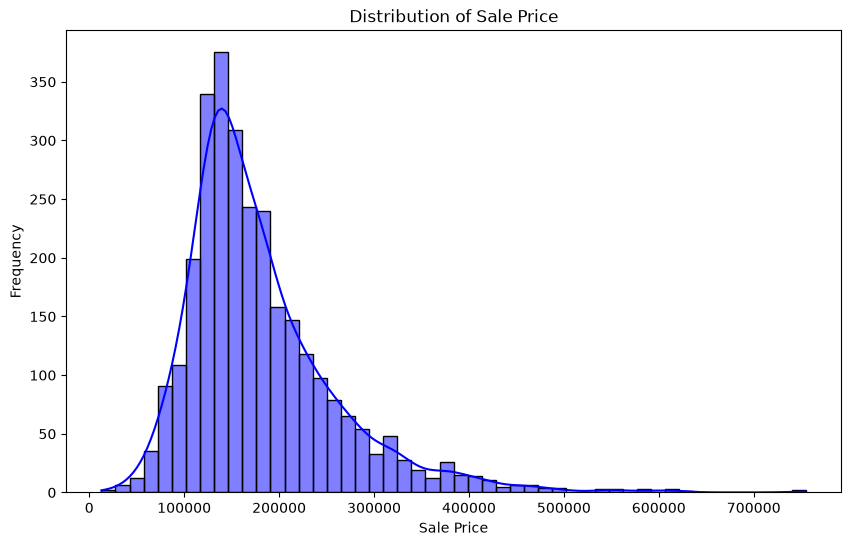

In [7]:
plt.figure(figsize=(10, 6))
sns.histplot(df['SalePrice'], kde=True, bins=50, color='blue')
plt.title('Distribution of Sale Price')
plt.xlabel('Sale Price')
plt.ylabel('Frequency')
plt.show()

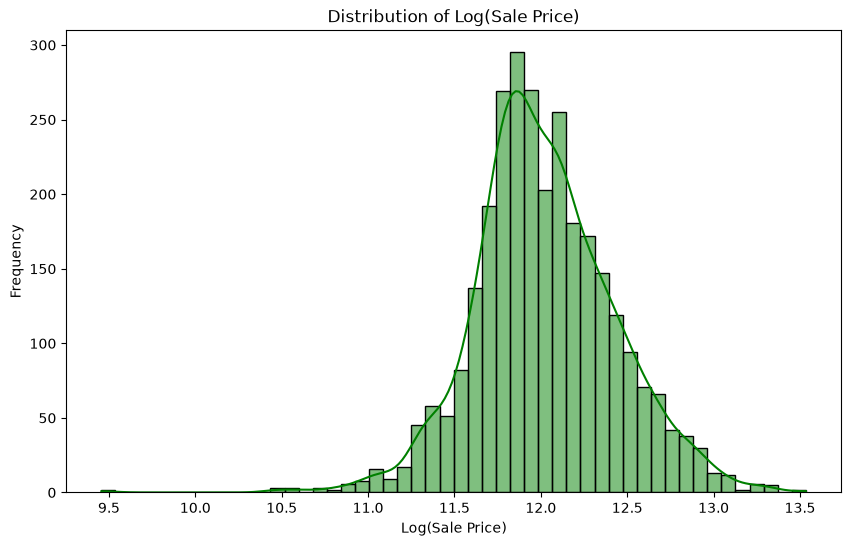

In [8]:
df['SalePrice_Log'] = np.log(df['SalePrice'])

plt.figure(figsize=(10, 6))
sns.histplot(df['SalePrice_Log'], kde=True, bins=50, color='green')
plt.title('Distribution of Log(Sale Price)')
plt.xlabel('Log(Sale Price)')
plt.ylabel('Frequency')
plt.show()

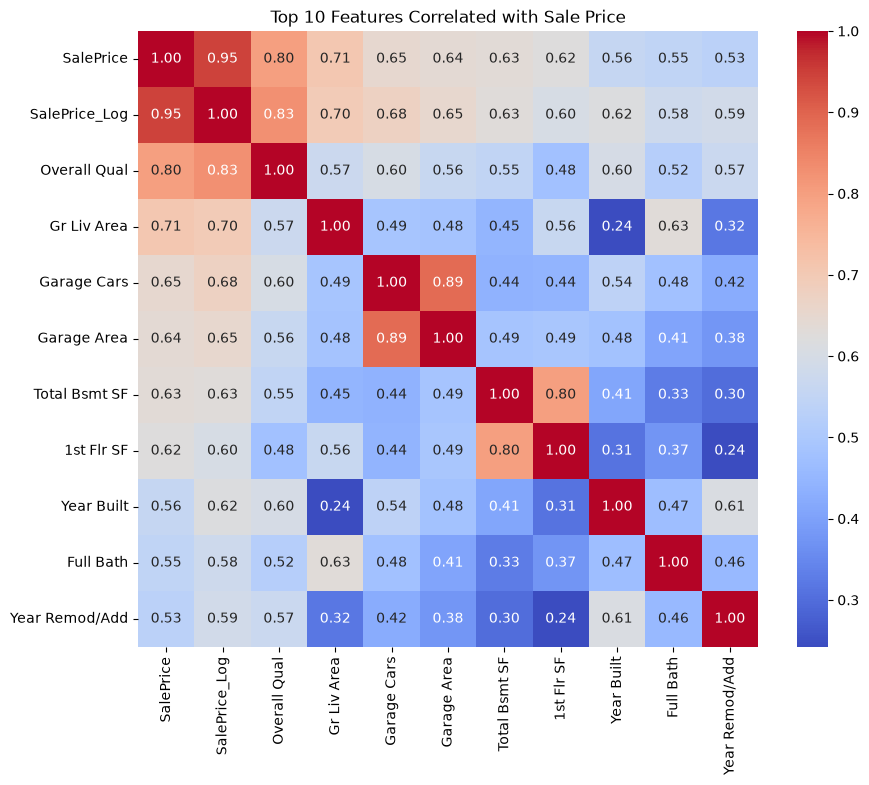

In [9]:
numeric_df = df.select_dtypes(include=[np.number])
corr_matrix = numeric_df.corr()

top_features = corr_matrix['SalePrice'].sort_values(ascending=False).head(11).index

plt.figure(figsize=(10, 8))
sns.heatmap(df[top_features].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Top 10 Features Correlated with Sale Price')
plt.show()

In [10]:
df['HouseAge'] = df['Yr Sold'] - df['Year Built']
df['RemodelAge'] = df['Yr Sold'] - df['Year Remod/Add']
df['TotalSF'] = df['Total Bsmt SF'] + df['1st Flr SF'] + df['2nd Flr SF']

df = df.drop(['Order', 'PID', 'Year Built', 'Year Remod/Add', 'Yr Sold', 'Mo Sold'], axis=1)

categorical_cols = df.select_dtypes(include=['object']).columns
df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

print(df.shape)

(2926, 274)


C:\Users\tharu\AppData\Local\Temp\ipykernel_13248\204471476.py:7: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include=['object']).columns


In [11]:
from sklearn.model_selection import train_test_split

X = df.drop(['SalePrice', 'SalePrice_Log'], axis=1)
y = df['SalePrice_Log']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(X_train.shape)
print(X_test.shape)

(2340, 272)
(586, 272)


In [12]:
import xgboost as xgb
from sklearn.metrics import mean_squared_error
import numpy as np

model_xgb = xgb.XGBRegressor(n_estimators=500, learning_rate=0.05, random_state=42)
model_xgb.fit(X_train, y_train)

y_pred = model_xgb.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(rmse)

0.10510830244260097


In [13]:
%pip install --upgrade xgboost

Note: you may need to restart the kernel to use updated packages.


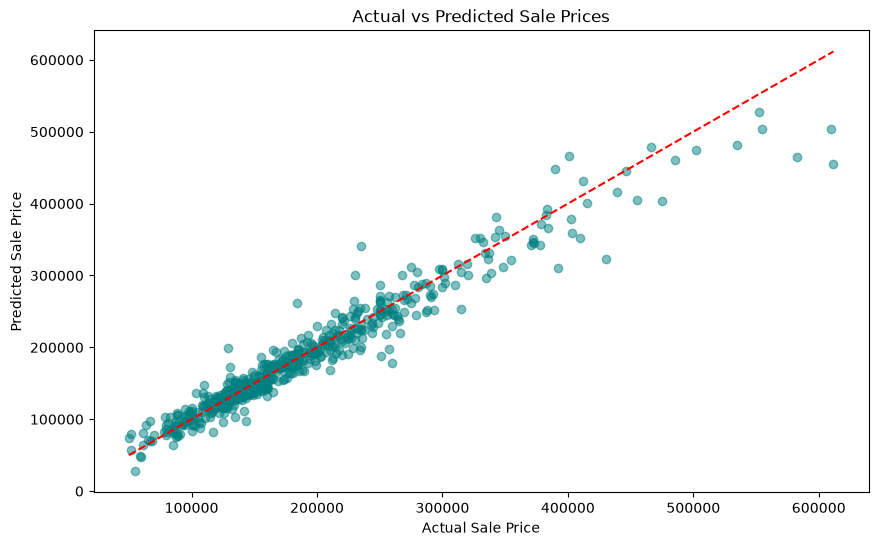

In [14]:
plt.figure(figsize=(10, 6))
plt.scatter(np.exp(y_test), np.exp(y_pred), alpha=0.5, color='teal')
plt.plot([np.exp(y_test).min(), np.exp(y_test).max()], [np.exp(y_test).min(), np.exp(y_test).max()], color='red', linestyle='--')
plt.title('Actual vs Predicted Sale Prices')
plt.xlabel('Actual Sale Price')
plt.ylabel('Predicted Sale Price')
plt.show()

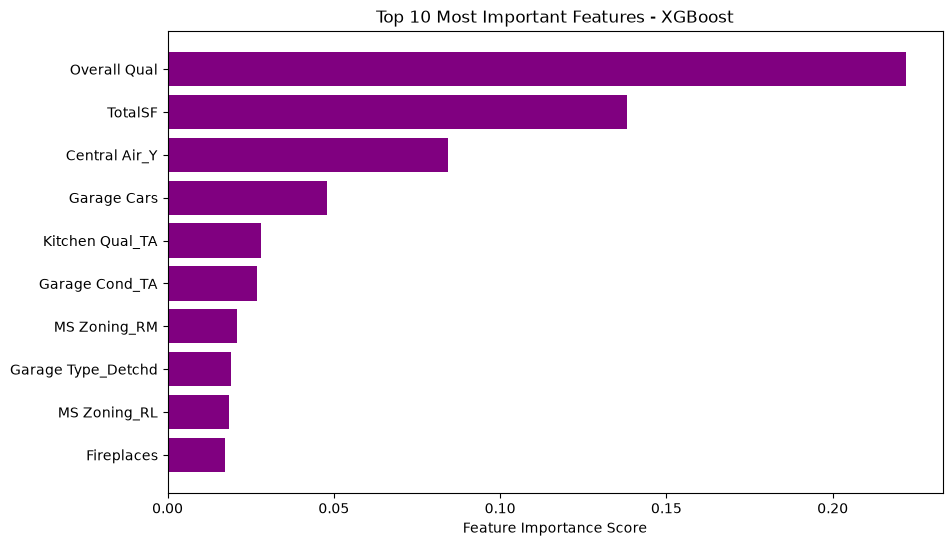

In [15]:
importance = model_xgb.feature_importances_
sorted_idx = np.argsort(importance)[-10:]

plt.figure(figsize=(10, 6))
plt.barh(range(10), importance[sorted_idx], align='center', color='purple')
plt.yticks(range(10), X.columns[sorted_idx])
plt.title('Top 10 Most Important Features - XGBoost')
plt.xlabel('Feature Importance Score')
plt.show()

In [16]:
import joblib

joblib.dump(model_xgb, 'xgboost_house_price_model.pkl')

print("Model saved successfully!")

Model saved successfully!


In [17]:

top_features_web = ['Overall Qual', 'TotalSF', 'Garage Cars', 'Central Air_Y']
X_web = df[top_features_web].astype(float).values
y_web = df['SalePrice_Log'].values


model_web = xgb.XGBRegressor(n_estimators=500, learning_rate=0.05, random_state=42)
model_web.fit(X_web, y_web)


joblib.dump(model_web, 'web_model.pkl')
print("Web Model saved successfully!")

Web Model saved successfully!


In [19]:
import joblib
import xgboost as xgb

top_features_web = [
    'Overall Qual', 'TotalSF', 'Garage Cars', 'Central Air_Y', 
    'Full Bath', 'Fireplaces', 'HouseAge', 'TotRms AbvGrd', 'Bedroom AbvGr'
]

X_web = df[top_features_web].astype(float).values
y_web = df['SalePrice_Log'].values

model_web = xgb.XGBRegressor(n_estimators=500, learning_rate=0.05, random_state=42)
model_web.fit(X_web, y_web)

joblib.dump(model_web, 'web_model.pkl')
print("Updated Web Model with Bedrooms saved successfully!")

Updated Web Model with Bedrooms saved successfully!


In [20]:
from sklearn.metrics import r2_score

r2 = r2_score(y_test, y_pred)

print(f"R^2 Score: {r2:.4f}")

R^2 Score: 0.9387
